# Prep notebook 3: Build H3 cells / zones and map them to networks

Two related concerns in one notebook:

1. **Aggregate data to H3 cells** (and roll up to zones). Sets up the
   geo-unit hierarchy that downstream notebooks consume.
2. **Snap each unit to network nodes** for each of the three networks
   (walk, bike, car). Pre-computes the `node_id_*` + `snap_dist_*`
   columns that downstream OD-pair construction needs.

Aggregates the four data layers prepared in notebooks 1 & 2 onto an
H3 hex grid:

- **Population** (GHSL 100 m raster) → per-cell sum.
- **Employment** (per-building FTE × 3 NOGA sectors) → per-cell sum.
- **Buildings** → per-cell count.
- **POIs** (per-category counts + weights) → per-cell sums.

**Two geo layers**, built on H3's hierarchical hex grid:

- **Cells** at resolution 10 (~15,000 m² / ~66 m edge) — the finest
  analysis unit; matches the minimal example for consistency.
- **Zones** at resolution 8 (~700,000 m² / ~460 m edge) — parent of
  cells; the zone-tier index aperta's `get_pairs` uses for the middle
  (`cells_to_zones`) and far (`zones_to_zones`) tiers.

Per-zone data columns (population, employment, POIs, etc.) are
pre-aggregated by sum from cells; aperta's `dest_values` reads them
directly during accessibility computation.

**Lookup strategy.** Rather than materialise polygons for every H3
cell in the destination polygon (~270k at res 10 — wasteful), we look
up each input point's H3 cell ID directly with `h3.latlng_to_cell`,
group, then materialise polygons only for the (much smaller) set of
cells that actually receive data. After filtering empty cells, the
output is typically O(100k) cells rather than O(300k).

**Filter.** A cell is kept iff it has at least one of:
`population > 0`, `employment_total > 0`, or `Σ POI counts > 0`.
Cells containing only sheds, garages, or barns (i.e. building_count >
0 but employment 0 and no POIs) are dropped — they're empty for
accessibility purposes.

**Building → cell mapping** is saved separately as a CSV so that
cell-level accessibility metrics can later be ported back to
individual buildings for fine-grained visualisation (same values,
more granular display).

In [1]:
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from shapely.geometry import Polygon

from aperta import network_processing

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

PREPARED_DIR = Path('../data/prepared')
CRS_METRIC = 'EPSG:2056'   # Swiss LV95
CRS_GEO = 'EPSG:4326'      # H3 always works in lat/lng

H3_RES_CELLS = 10    # ~66 m edge  / ~15,000 m² per hex
H3_RES_ZONES = 8     # ~460 m edge / ~700,000 m² per hex; parent of res-10

/opt/miniconda3/envs/aperta/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. Load inputs from notebooks 1 & 2

In [2]:
dest_polygon = gpd.read_file(PREPARED_DIR / 'dest_polygon.gpkg').geometry.iloc[0]
buildings = gpd.read_file(PREPARED_DIR / 'employment_per_building.gpkg')
pois = gpd.read_file(PREPARED_DIR / 'pois.gpkg')

print(f"Destination polygon: {dest_polygon.area / 1e6:.1f} km²")
print(f"Buildings:           {len(buildings):,}")
print(f"POIs:                {len(pois):,}")

Destination polygon: 6562.2 km²
Buildings:           554,135
POIs:                11,219


## 2. Look up H3 cell ID for every input point

All three input sources (buildings, POIs, population pixels) get their
cell ID computed directly from lat/lng — no spatial join needed yet.

### 2a. Building centroids → cell

In [3]:
b_centroids_4326 = buildings.geometry.centroid.to_crs(CRS_GEO)
buildings['cell_id'] = [
    h3.latlng_to_cell(p.y, p.x, H3_RES_CELLS) for p in b_centroids_4326
]
print(f"{buildings['cell_id'].nunique():,} unique cells contain at least one building.")

102,263 unique cells contain at least one building.


### 2b. POI centroids → cell

In [4]:
pois_4326 = pois.to_crs(CRS_GEO)
pois['cell_id'] = [
    h3.latlng_to_cell(p.y, p.x, H3_RES_CELLS) for p in pois_4326.geometry
]
print(f"{pois['cell_id'].nunique():,} unique cells contain at least one POI.")

9,576 unique cells contain at least one POI.


### 2c. GHSL population pixel centroids → cell

Each non-zero raster pixel contributes its full population value to
the H3 cell its centroid falls in. Asymmetric attribution (pixel
attributed to one cell, not split across multiple) — keeps the total
population invariant: `Σ cells['population'] == Σ raster pixels`.

In [5]:
POP_RASTER = PREPARED_DIR / 'population_ghsl_100m.tif'
with rasterio.open(POP_RASTER) as src:
    pop_arr = src.read(1)
    raster_crs = src.crs
    rows, cols = np.indices(pop_arr.shape)
    xs, ys = rasterio.transform.xy(src.transform, rows.flatten(), cols.flatten())
    pop_values = pop_arr.flatten()

# Drop zero pixels — saves 80 %+ of work, doesn't affect any aggregate.
mask = pop_values > 0
xs = np.array(xs)[mask]
ys = np.array(ys)[mask]
pop_values = pop_values[mask].astype(float)

# Reproject pixel centroids (Mollweide → EPSG:4326) for H3 lookup.
pop_pts_4326 = gpd.GeoSeries(
    gpd.points_from_xy(xs, ys), crs=raster_crs,
).to_crs(CRS_GEO)
pop_df = pd.DataFrame({
    'population': pop_values,
    'cell_id': [h3.latlng_to_cell(p.y, p.x, H3_RES_CELLS) for p in pop_pts_4326],
})
print(f"{len(pop_df):,} non-zero GHSL pixels across "
      f"{pop_df['cell_id'].nunique():,} unique cells "
      f"(total {pop_df['population'].sum():,.0f} people).")

161,176 non-zero GHSL pixels across 126,975 unique cells (total 1,551,024 people).


## 3. Aggregate per cell

In [6]:
# Population: sum pixel values per cell.
pop_per_cell = pop_df.groupby('cell_id')['population'].sum()

# Employment: sum 4 columns per cell (3 sectors + total).
EMP_COLS = ['employment_primary', 'employment_secondary',
            'employment_tertiary', 'employment_total']
emp_per_cell = buildings.groupby('cell_id')[EMP_COLS].sum()

# Building count per cell (useful diagnostic + potential overhead input).
building_count_per_cell = buildings.groupby('cell_id').size().rename('building_count')

# POIs: sum every numeric column per cell (covers both `<cat>` count and
# `<cat>_weight` for every category, deterministically detected via dtype).
poi_numeric_cols = [
    c for c in pois.columns
    if c not in ('geometry', 'cell_id') and pd.api.types.is_numeric_dtype(pois[c])
]
poi_per_cell = pois.groupby('cell_id')[poi_numeric_cols].sum()

print(f"\nAggregation produced columns:")
print(f"  population:        1")
print(f"  employment_*:      {len(EMP_COLS)}")
print(f"  building_count:    1")
print(f"  POI:               {len(poi_numeric_cols)}")


Aggregation produced columns:
  population:        1
  employment_*:      4
  building_count:    1
  POI:               6


## 4. Build the cells GeoDataFrame

Index = union of all cell IDs that received any data. Each layer joins
in via the cell ID; missing entries get 0. Geometry is materialised
only at this point — the H3-direct lookup means we never touch cells
with no data on them.

In [7]:
all_cell_ids = sorted(
    set(pop_per_cell.index) | set(emp_per_cell.index) | set(poi_per_cell.index)
)
print(f"{len(all_cell_ids):,} unique cells with any data.")

# Assemble the attribute table.
cells = pd.DataFrame(index=pd.Index(all_cell_ids, name='cell_id'))
cells['population'] = pop_per_cell.reindex(cells.index, fill_value=0.0).astype(float)
cells = cells.join(emp_per_cell.reindex(cells.index, fill_value=0.0))
cells = cells.join(building_count_per_cell.reindex(cells.index, fill_value=0).astype(int))
cells = cells.join(poi_per_cell.reindex(cells.index, fill_value=0.0))

# Materialise polygon geometry from H3 cell IDs.
def _h3_cell_to_polygon(cell: str) -> Polygon:
    """Shapely Polygon for an H3 cell, in (lng, lat) order."""
    return Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])

cells['geometry'] = [_h3_cell_to_polygon(c) for c in cells.index]
cells = gpd.GeoDataFrame(cells, geometry='geometry', crs=CRS_GEO).to_crs(CRS_METRIC)

# Add zone_id (H3 res-8 parent of each res-10 cell).
cells['zone_id'] = [h3.cell_to_parent(c, H3_RES_ZONES) for c in cells.index]

142,729 unique cells with any data.


## 5. Filter empty cells

Keep cells with population > 0, OR employment, OR at least one POI.
Cells with only sheds / garages / barns get dropped — building_count
is informative but not sufficient on its own.

In [8]:
poi_count_cols = [c for c in poi_numeric_cols if not c.endswith('_weight')]
non_empty = (
    (cells['population'] > 0)
    | (cells['employment_total'] > 0)
    | (cells[poi_count_cols].sum(axis=1) > 0)
)
n_before = len(cells)
cells = cells[non_empty].copy()
print(f"Cells: {n_before:,} → {len(cells):,} after filtering empty "
      f"({(1 - len(cells)/n_before) * 100:.1f} % dropped).")

Cells: 142,729 → 142,209 after filtering empty (0.4 % dropped).


## 6. Build zones (sum-aggregated from cells)

Zones (H3 res 8) are derived from `cells['zone_id']`, so by construction
every zone contains at least one non-empty cell — no separate filter
step needed.

All cell-level data columns (population, employment, building count,
POI counts + weights) are aggregated by **sum** to the parent zone.
Aperta's `dest_values` reads these pre-aggregated columns at
accessibility-computation time for the `cells_to_zones` (middle) and
`zones_to_zones` (far) tiers.

In [9]:
# Identify the numeric data columns to sum-aggregate (everything except
# the structural columns).
DATA_COLS = [c for c in cells.columns
             if c not in ('geometry', 'zone_id')]

agg = cells.groupby('zone_id')[DATA_COLS].sum()
zone_ids = sorted(agg.index)
zones = gpd.GeoDataFrame(
    agg.reindex(zone_ids).assign(
        geometry=[_h3_cell_to_polygon(z) for z in zone_ids],
    ),
    geometry='geometry', crs=CRS_GEO,
).to_crs(CRS_METRIC)
zones.index.name = 'zone_id'
print(f"Zones: {len(zones):,} (avg {len(cells)/len(zones):.1f} cells each).")

Zones: 8,903 (avg 16.0 cells each).


## 7. Snap units to network nodes — per network

For each geo layer (cells, zones), find the nearest node on each of the
three networks (walk, bike, car). Result is stored as per-mode columns
(`node_id_walk`, `node_id_bike`, `node_id_car`, plus `snap_dist_*` in
metres) — keeping all three in one DataFrame means downstream OD-pair
construction just passes the right `node_column=` argument.

Snap distances are reused downstream as the cell-to-network-node
first-mile / last-mile component of trip overheads.

In [10]:
walk_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'walk_graph.graphml')
bike_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'bike_graph.graphml')
car_graph  = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'car_graph.graphml')


def snap_layer_to_all_networks(layer: gpd.GeoDataFrame) -> None:
    """Mutate `layer` to add node-id + snap-distance columns for each network."""
    centroids = layer.copy()
    centroids['geometry'] = centroids.geometry.centroid
    for graph, label in [(walk_graph, 'walk'),
                         (bike_graph, 'bike'),
                         (car_graph,  'car')]:
        nid, dist = network_processing.snap_to_network_nodes(centroids, graph)
        layer[f'node_id_{label}'] = nid
        layer[f'snap_dist_{label}'] = dist


for layer, name in [(cells, 'cells'), (zones, 'zones')]:
    snap_layer_to_all_networks(layer)
    print(f"  Snapped {name}: "
          f"walk {layer['node_id_walk'].notna().sum():>6,} "
          f"(median dist {layer['snap_dist_walk'].median():.0f} m), "
          f"bike {layer['node_id_bike'].notna().sum():>6,}, "
          f"car  {layer['node_id_car'].notna().sum():>6,}")

  Snapped cells: walk 142,209 (median dist 66 m), bike 142,209, car  142,209
  Snapped zones: walk  8,903 (median dist 115 m), bike  8,903, car   8,903


## 8. Save outputs

- `cells.gpkg` — cell-indexed GeoDataFrame with geometry + every
  aggregated attribute column + `zone_id` linker +
  `node_id_{walk,bike,car}` + `snap_dist_{walk,bike,car}`.
  Consumed directly by `accessibility.ipynb`.
- `zones.gpkg` — zone-indexed GeoDataFrame; same data + node-id
  columns as `cells`, sum-aggregated for data columns.
- `building_to_cell.csv` — `building_id → cell_id` mapping. Used to
  port cell-level accessibility metrics back to individual buildings
  for fine-grained visualisation (same values, more granular display).
  `building_id` is the row index of `employment_per_building.gpkg`
  loaded by `gpd.read_file`.

In [11]:
cells.to_file(PREPARED_DIR / 'cells.gpkg', driver='GPKG')
zones.to_file(PREPARED_DIR / 'zones.gpkg', driver='GPKG')
buildings[['cell_id']].to_csv(PREPARED_DIR / 'building_to_cell.csv')
print(f"\nSaved:")
print(f"  cells.gpkg              ({len(cells):,} cells)")
print(f"  zones.gpkg              ({len(zones):,} zones)")
print(f"  building_to_cell.csv    ({len(buildings):,} rows)")


Saved:
  cells.gpkg              (142,209 cells)
  zones.gpkg              (8,903 zones)
  building_to_cell.csv    (554,135 rows)


## 9. Validation

Cross-layer validation: the sum-aggregation is exact, so per-data-column
totals are identical at both layers (and match the input totals to the
extent that the input got assigned to a cell that survived the
empty-cell filter).

In [12]:
print(f"\n--- Per-layer validation (sums should all match) ---")
print(f"                       cells           zones         input")
for col, input_total in [
    ('population',       pop_df['population'].sum()),
    ('employment_total', buildings['employment_total'].sum()),
    ('building_count',   len(buildings)),
]:
    print(f"  {col:18s} {cells[col].sum():>10,.0f}    "
          f"{zones[col].sum():>10,.0f}    "
          f"{input_total:>10,.0f}")


--- Per-layer validation (sums should all match) ---
                       cells           zones         input
  population          1,551,024     1,551,024     1,551,024
  employment_total      722,153       722,153       722,153
  building_count        553,560       553,560       554,135


## Appendix: visualisation

Two optional figures. First: the same data (population) at both H3
layers — shows the progressive aggregation from fine-grained cells
(~95k) to coarser zones (~5.5k). Useful for eyeballing layer
coverage and the resolution trade-off in aperta's tiered OD design.
Second: per-cell triptych showing population, employment, and total
POI count side by side.

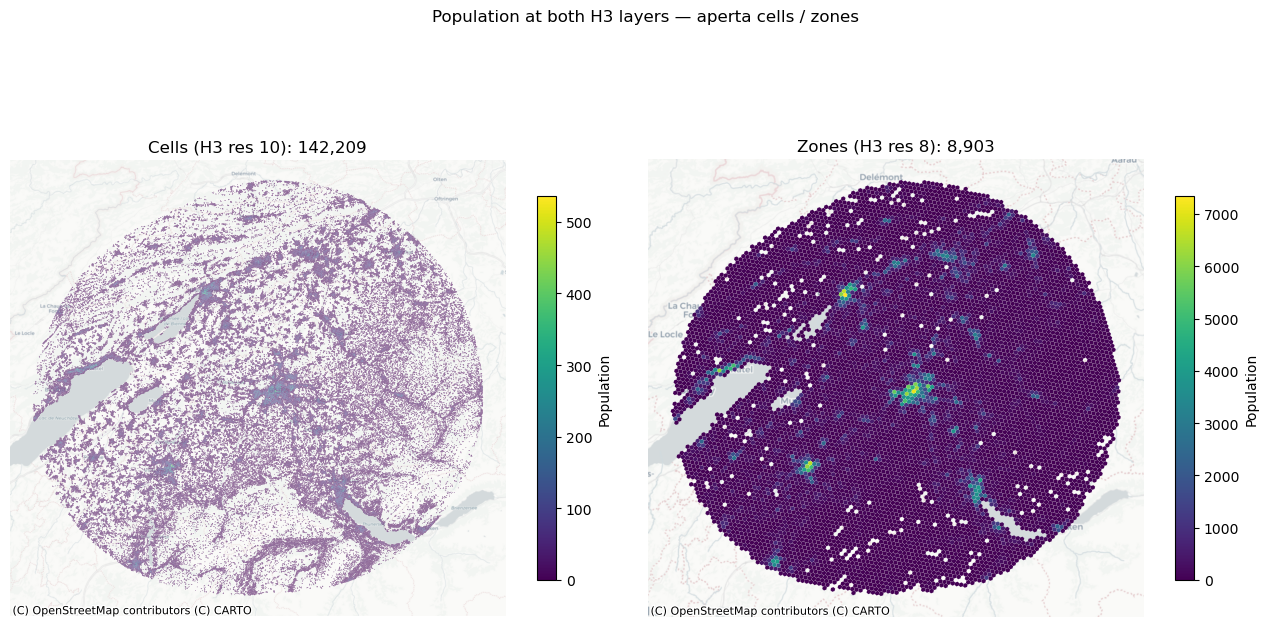

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, gdf, title in [
    (axes[0], cells, f'Cells (H3 res 10): {len(cells):,}'),
    (axes[1], zones, f'Zones (H3 res 8): {len(zones):,}'),
]:
    gdf.plot(
        column='population', ax=ax, legend=True, cmap='viridis',
        edgecolor='white', linewidth=0.05,
        legend_kwds={'shrink': 0.6, 'label': 'Population'},
    )
    cx.add_basemap(
        ax, source=cx.providers.CartoDB.Positron(r='@2x'), crs=CRS_METRIC,
    )
    ax.set_title(title)
    ax.set_axis_off()
plt.suptitle('Population at both H3 layers — aperta cells / zones',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

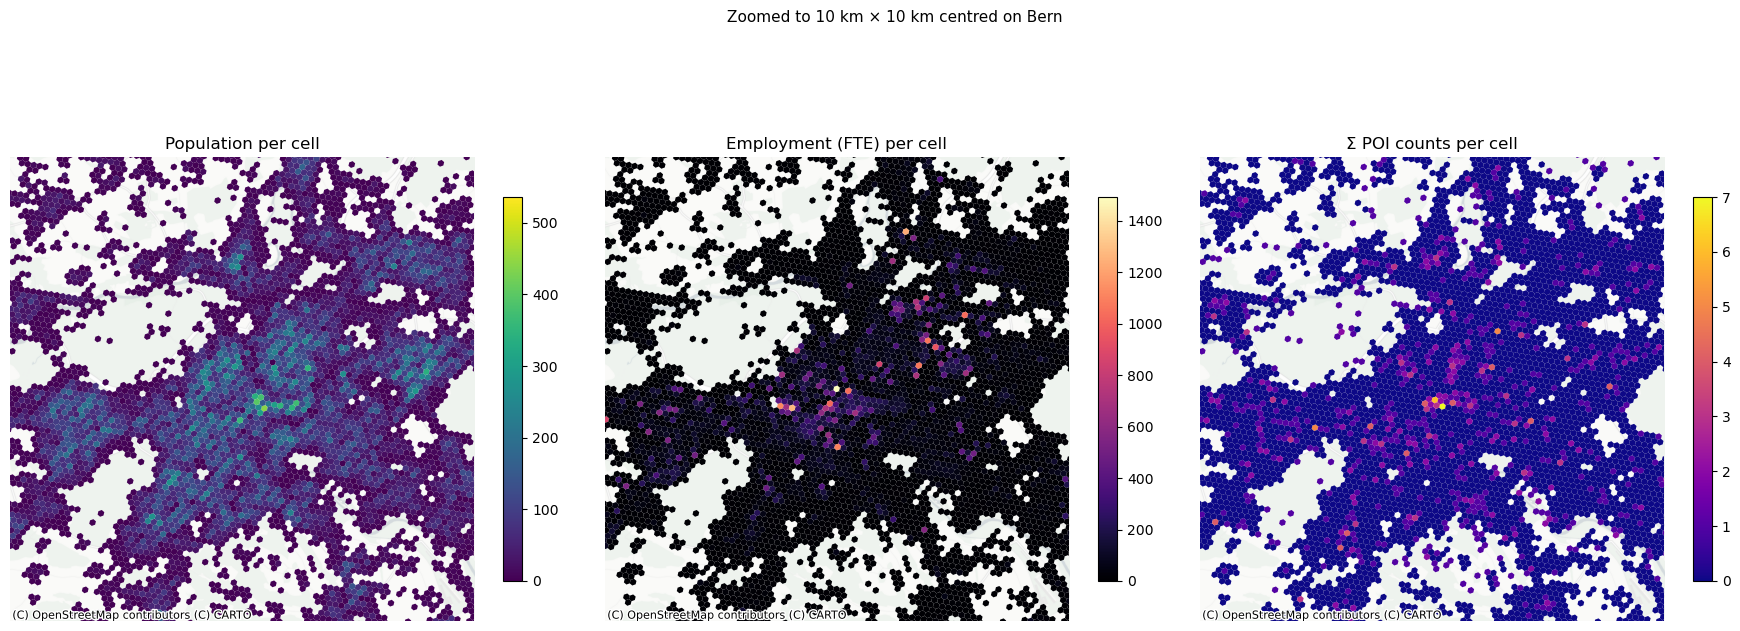

In [14]:
# Zoom box centred on Bern (LV95). The full study area is ~50 km across,
# which makes individual H3-res-10 cells (~130 m diameter) hard to see;
# this crop shows roughly inner Bern + immediate suburbs so per-cell
# values are legible. Adjust ZOOM_HALF_WIDTH_M to widen / tighten.
BERN_CENTER_LV95 = (2_600_000, 1_200_000)
ZOOM_HALF_WIDTH_M = 5_000   # → 10 km × 10 km extent

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, col, title, cmap in [
    (axes[0], 'population',       'Population per cell',           'viridis'),
    (axes[1], 'employment_total', 'Employment (FTE) per cell',     'magma'),
    (axes[2], None,                'Σ POI counts per cell',         'plasma'),
]:
    if col is None:
        cells['_poi_total'] = cells[poi_count_cols].sum(axis=1)
        col = '_poi_total'
    cells.plot(
        column=col, ax=ax, legend=True, cmap=cmap, edgecolor='none',
        legend_kwds={'shrink': 0.6},
    )
    # Set zoom extents BEFORE add_basemap so contextily fetches tiles
    # at the appropriate zoom level rather than for the full study area.
    ax.set_xlim(BERN_CENTER_LV95[0] - ZOOM_HALF_WIDTH_M,
                BERN_CENTER_LV95[0] + ZOOM_HALF_WIDTH_M)
    ax.set_ylim(BERN_CENTER_LV95[1] - ZOOM_HALF_WIDTH_M,
                BERN_CENTER_LV95[1] + ZOOM_HALF_WIDTH_M)
    cx.add_basemap(
        ax, source=cx.providers.CartoDB.Positron(r='@2x'), crs=CRS_METRIC,
    )
    ax.set_title(title)
    ax.set_axis_off()
cells.drop(columns=['_poi_total'], inplace=True)
plt.suptitle(f'Zoomed to {2 * ZOOM_HALF_WIDTH_M // 1000} km × '
             f'{2 * ZOOM_HALF_WIDTH_M // 1000} km centred on Bern',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()